In [7]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv("data/Lifestyle Dataset of Students at Topfaith University.csv")

In [9]:
data.head()

,Timestamp,1. Age,2. Gender,3. Level of Study,4. Programme (Faculty),5. How many hours do you sleep on average per day?,6. Do you feel well rested most mornings?,7. How many hours do you study daily outside lectures?,8. Average daily screen time (excluding lectures)?\r\n,9. How often do you engage in physical exercise per week?,10. How long does each exercise session usually last?,11. How would you describe you eating habits?,12. How often do you skip meals due to academic workload?,13. How often do you feel stressed due to academic activities,14. How well do you manage academic stress?
0,2026/02/23 3:43:07 PM GMT+1,19 -21,Male,400 Level,Computing and Applied Sciences,4-5 hours,Sometimes,1-2 hours,2-4 hours,1-2 times,20-40 minutes,Very healthy,Sometimes,Often,Fairly well
1,2026/02/23 7:03:14 PM GMT+1,19 -21,Female,400 Level,Computing and Applied Sciences,4-5 hours,Sometimes,3-4 hours,5-7 hours,3-4time,40-60 minutes,Very healthy,Sometimes,Often,Very well
2,2026/02/25 6:09:31 AM GMT+1,19 -21,Female,300 Level,Engineering,6-7 hours,Sometimes,Less than 1 hour,2-4 hours,1-2 times,20-40 minutes,Fairly healthy,Often,Often,Fairly well
3,2026/02/25 6:19:49 AM GMT+1,16 - 18,Female,100 Level,Law,4-5 hours,Rarely,1-2 hours,5-7 hours,Never,Less then 20 minutes,Fairly healthy,Sometimes,Always,Fairly well
4,2026/02/25 6:32:10 AM GMT+1,22 -24,Male,400 Level,Computing and Applied Sciences,Less than 4 hours,Sometimes,3-4 hours,2-4 hours,3-4time,More than 60 minutes,Unhealthy,Sometimes,Never,Very well


In [10]:
# Removing irrelevant columns
data.drop(columns=["Timestamp"], inplace=True)

In [11]:
data.head()

,1. Age,2. Gender,3. Level of Study,4. Programme (Faculty),5. How many hours do you sleep on average per day?,6. Do you feel well rested most mornings?,7. How many hours do you study daily outside lectures?,8. Average daily screen time (excluding lectures)?\r\n,9. How often do you engage in physical exercise per week?,10. How long does each exercise session usually last?,11. How would you describe you eating habits?,12. How often do you skip meals due to academic workload?,13. How often do you feel stressed due to academic activities,14. How well do you manage academic stress?
0,19 -21,Male,400 Level,Computing and Applied Sciences,4-5 hours,Sometimes,1-2 hours,2-4 hours,1-2 times,20-40 minutes,Very healthy,Sometimes,Often,Fairly well
1,19 -21,Female,400 Level,Computing and Applied Sciences,4-5 hours,Sometimes,3-4 hours,5-7 hours,3-4time,40-60 minutes,Very healthy,Sometimes,Often,Very well
2,19 -21,Female,300 Level,Engineering,6-7 hours,Sometimes,Less than 1 hour,2-4 hours,1-2 times,20-40 minutes,Fairly healthy,Often,Often,Fairly well
3,16 - 18,Female,100 Level,Law,4-5 hours,Rarely,1-2 hours,5-7 hours,Never,Less then 20 minutes,Fairly healthy,Sometimes,Always,Fairly well
4,22 -24,Male,400 Level,Computing and Applied Sciences,Less than 4 hours,Sometimes,3-4 hours,2-4 hours,3-4time,More than 60 minutes,Unhealthy,Sometimes,Never,Very well


In [12]:
# Renaming the columns name
data.columns = [
    "Age",
    "Gender",
    "Level",
    "Faculty",
    "SleepHours",
    "Rested",
    "StudyHours",
    "ScreenTime",
    "ExerciseFreq",
    "ExerciseDuration",
    "DietQuality",
    "MealSkipping",
    "StressFrequency",
    "StressManagement"
]

In [13]:
# Converting text to numbers
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()

categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    data[col] = encode.fit_transform(data[col])

data.head()    

,Age,Gender,Level,Faculty,SleepHours,Rested,StudyHours,ScreenTime,ExerciseFreq,ExerciseDuration,DietQuality,MealSkipping,StressFrequency,StressManagement
0,1,1,3,1,0,2,0,0,0,0,2,3,2,0
1,1,0,3,1,0,2,1,1,1,1,2,3,2,3
2,1,0,2,2,1,2,2,0,0,0,0,2,2,0
3,0,0,0,3,0,1,0,1,3,2,0,3,0,0
4,2,1,3,1,2,2,1,0,1,3,1,3,1,3


In [14]:
# Checking outliers using boxplots
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure()
    data.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

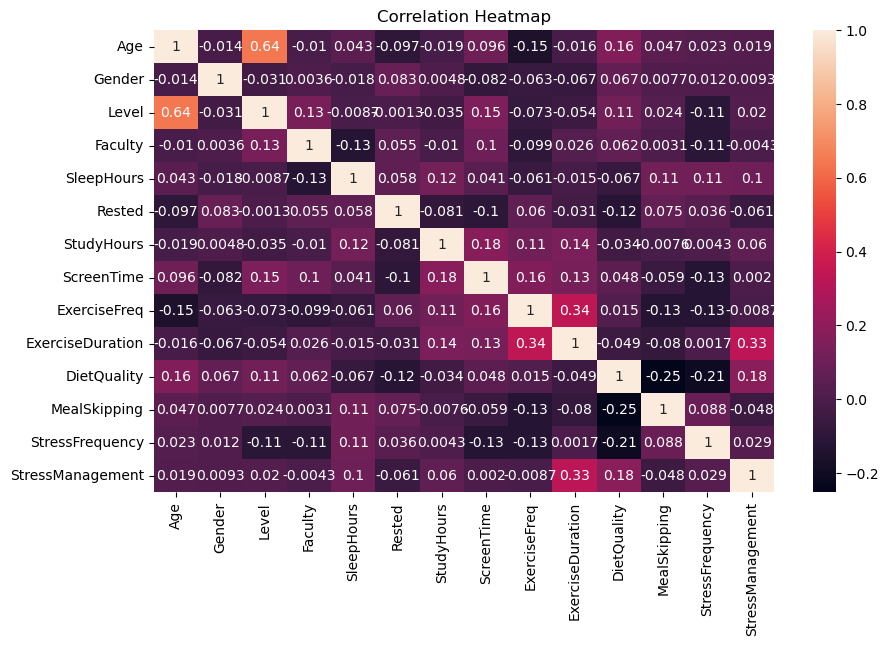

In [15]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# creating a new column for the scores that will be attributed to the lifestyle category
data["score"] = (
    (data["SleepHours"] >= 7).astype(int) +
    (data["ExerciseFreq"] >= 2).astype(int) +
    (data["ScreenTime"] <= 5).astype(int) +
    (data["DietQuality"] == 2).astype(int) +
    (data["StressFrequency"] == 0).astype(int)
)

In [17]:
# Assiging score to Lifesyle class
def classify(Score):
    if Score >= 4:
        return 2 # Healthy
    elif Score >= 2:
        return 1 # Moderately Healthy
    else:
        return 0 # Unhealthy


data["Lifestyle"] = data["score"].apply(classify)  


In [18]:
data.head()

,Age,Gender,Level,Faculty,SleepHours,Rested,StudyHours,ScreenTime,ExerciseFreq,ExerciseDuration,DietQuality,MealSkipping,StressFrequency,StressManagement,score,Lifestyle
0,1,1,3,1,0,2,0,0,0,0,2,3,2,0,2,1
1,1,0,3,1,0,2,1,1,1,1,2,3,2,3,2,1
2,1,0,2,2,1,2,2,0,0,0,0,2,2,0,1,0
3,0,0,0,3,0,1,0,1,3,2,0,3,0,0,3,1
4,2,1,3,1,2,2,1,0,1,3,1,3,1,3,1,0


In [19]:
# Saveing clean dataset
data.to_csv("Cleaned_dataset.csv", index=False)

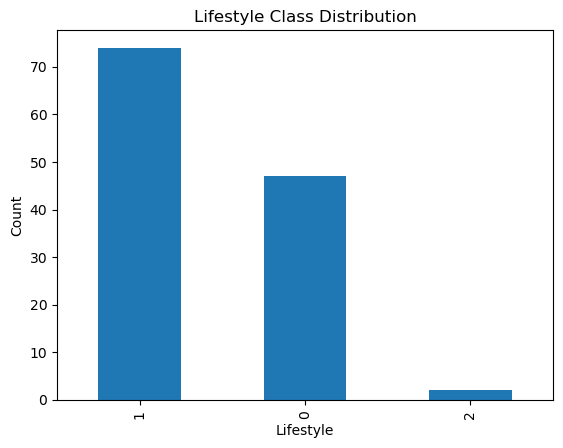

In [20]:
data["Lifestyle"].value_counts().plot(kind="bar")
plt.title("Lifestyle Class Distribution")
plt.ylabel("Count")
plt.show()

Below are simple comparisons of key features by lifestyle class. First we compute the average values for each feature and show them in an easy-to-read bar chart.

Lifestyle categories: 0 = Unhealthy, 1 = Moderately Healthy, 2 = Healthy

Average feature values by lifestyle category:
           SleepHours  ScreenTime  ExerciseFreq  DietQuality  StressFrequency
Lifestyle                                                                    
0            1.106383    1.042553      0.255319     0.127660         2.361702
1            0.810811    1.162162      1.581081     0.945946         1.608108
2            1.500000    2.500000      3.000000     2.000000         0.000000


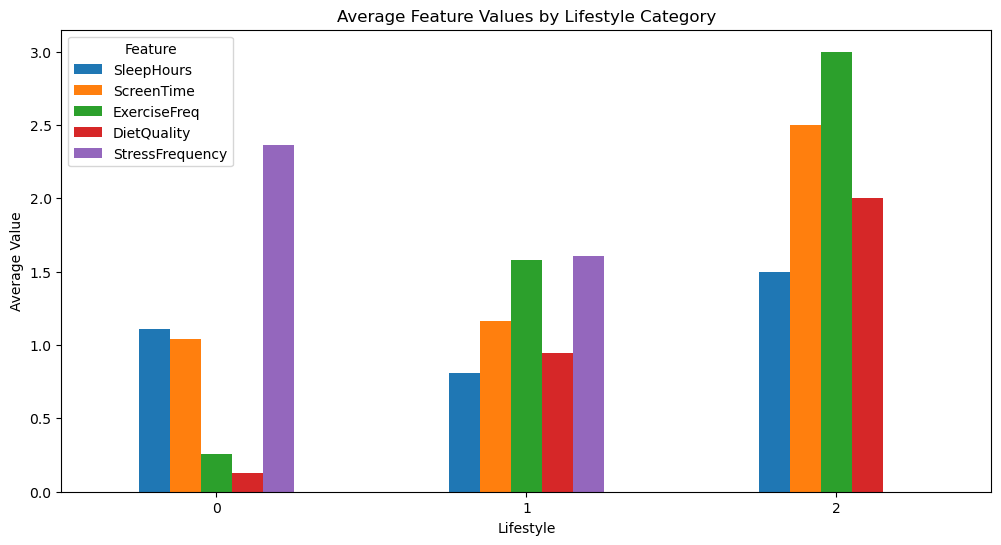

In [21]:
feature_means = data.groupby("Lifestyle")[["SleepHours", "ScreenTime", "ExerciseFreq", "DietQuality", "StressFrequency"]].mean()

print("Lifestyle categories: 0 = Unhealthy, 1 = Moderately Healthy, 2 = Healthy")
print("\nAverage feature values by lifestyle category:")
print(feature_means)

feature_means.plot(kind="bar", figsize=(12,6))
plt.title("Average Feature Values by Lifestyle Category")
plt.xlabel("Lifestyle")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

In [27]:
data["Lifestyle"].value_counts()

Lifestyle
1    74
0    47
2     2
Name: count, dtype: int64

In [28]:
X = data.drop(["Lifestyle","score"], axis=1)
y = data["Lifestyle"]

In [29]:
# Test, train split
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Spliting the dataset into two the test and train dataset

In [30]:
# Initializing the models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Decission Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

c:\Users\Rmrdc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rmrdc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rmrdc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      0.80   0.787013    0.80  0.785333
1        Decision Tree      0.92   0.892308    0.92  0.902533
2        Random Forest      0.92   0.892308    0.92  0.902533


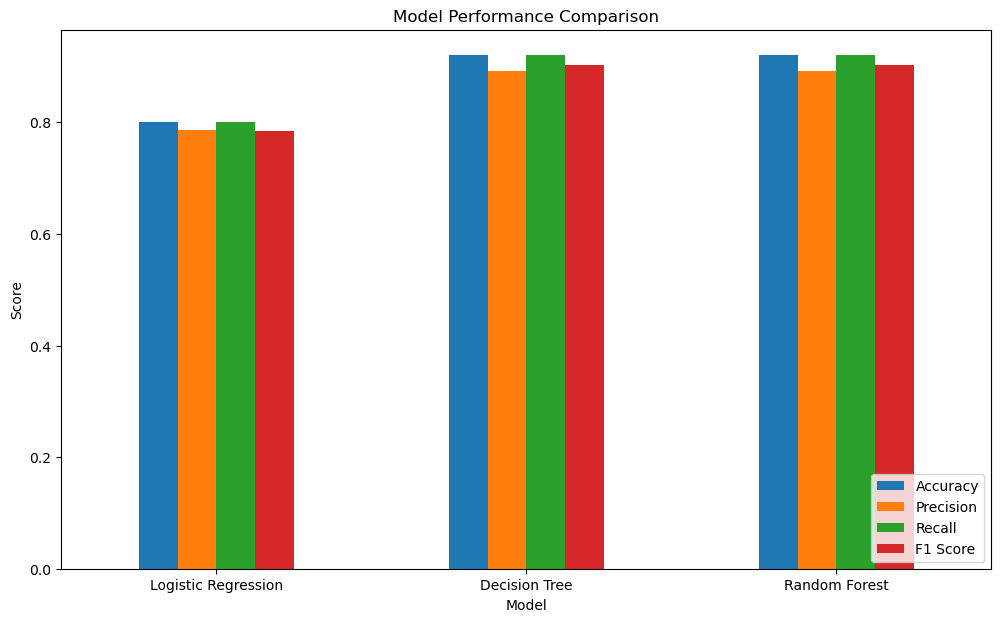

In [31]:
# Graphical comparison and representation of the three models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    accu = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    reca = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accu, prec, reca, f1])

results_data = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])    

print(results_data)

results_data.set_index("Model").plot(kind="bar", figsize=(12,7))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()